# 亚马逊供应链项目 - 数据质量评估报告
## Week 1 Deliverable
---
## Objective
1. Data structure & field inspection
2. Missing/duplicate/outlier detection
3. Data type compliance check
4. Preprocessing recommendations for Week 2

### Datasets
1. Amazon Sales Dataset (Kaggle synthetic)
2. Online Retail Dataset (UCI real-world)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

print("✅ Environment initialized")

✅ Environment initialized


In [2]:
# File paths (absolute path for MAC stability)
amazon_path = '/Users/huyujie/Documents/amazon-supply-chain-project/data/raw/amazon_sales_dataset.csv'
uci_path = '/Users/huyujie/Documents/amazon-supply-chain-project/data/raw/Online Retail.xlsx'

# Load datasets
df_amazon = pd.read_csv(amazon_path)
df_uci = pd.read_excel(uci_path)

print("✅ Datasets loaded")

✅ Datasets loaded


In [3]:
print("===== Amazon Sales Dataset Overview =====")
print(f"Shape: {df_amazon.shape[0]} rows, {df_amazon.shape[1]} columns\n")
print("First 5 rows:")
display(df_amazon.head())
print("\nData types & non-null counts:")
df_amazon.info()
print("\nNumeric statistics:")
display(df_amazon.describe())

===== Amazon Sales Dataset Overview =====
Shape: 100000 rows, 20 columns

First 5 rows:


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411



Data types & non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  object 
 1   OrderDate      100000 non-null  object 
 2   CustomerID     100000 non-null  object 
 3   CustomerName   100000 non-null  object 
 4   ProductID      100000 non-null  object 
 5   ProductName    100000 non-null  object 
 6   Category       100000 non-null  object 
 7   Brand          100000 non-null  object 
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  object 
 15  OrderStatus    100000 non-null  object 
 16  City           100000 non-null  object 
 17 

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


In [4]:
print("===== UCI Retail Dataset Overview =====")
print(f"Shape: {df_uci.shape[0]} rows, {df_uci.shape[1]} columns\n")
print("First 5 rows:")
display(df_uci.head())
print("\nData types & non-null counts:")
df_uci.info()
print("\nNumeric statistics:")
display(df_uci.describe())

===== UCI Retail Dataset Overview =====
Shape: 541909 rows, 8 columns

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Data types & non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Numeric statistics:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303



===== Amazon Sales Missing Values =====
No missing values

===== UCI Retail Missing Values =====


,Count,Rate (%)
CustomerID,135080,24.93
Description,1454,0.27


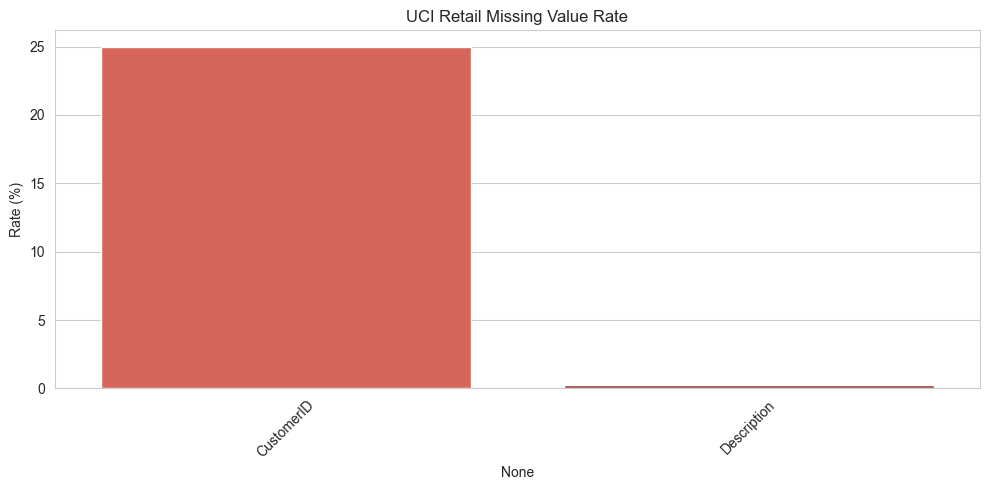

In [5]:
def analyze_missing(df, name):
    missing = df.isnull().sum().sort_values(ascending=False)
    missing_rate = (missing / len(df) * 100).round(2)
    result = pd.DataFrame({'Count': missing, 'Rate (%)': missing_rate})
    result = result[result['Count'] > 0]
    
    print(f"\n===== {name} Missing Values =====")
    if result.empty:
        print("No missing values")
    else:
        display(result)
        plt.figure(figsize=(10, 5))
        sns.barplot(x=result.index, y='Rate (%)', data=result, palette='Reds_d')
        plt.title(f'{name} Missing Value Rate')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    return result

# Run analysis
amazon_missing = analyze_missing(df_amazon, 'Amazon Sales')
uci_missing = analyze_missing(df_uci, 'UCI Retail')

In [6]:
def analyze_duplicates(df, name):
    dup_count = df.duplicated().sum()
    dup_rate = (dup_count / len(df) * 100).round(4)
    
    print(f"\n===== {name} Duplicates =====")
    print(f"Total rows: {len(df)}")
    print(f"Duplicate rows: {dup_count}")
    print(f"Duplicate rate: {dup_rate}%")
    
    if dup_count > 0:
        print("\nSample duplicates:")
        display(df[df.duplicated()].head())
    return dup_count, dup_rate

# Run analysis
amazon_dup = analyze_duplicates(df_amazon, 'Amazon Sales')
print("-"*50)
uci_dup = analyze_duplicates(df_uci, 'UCI Retail')


===== Amazon Sales Duplicates =====
Total rows: 100000
Duplicate rows: 0
Duplicate rate: 0.0%
--------------------------------------------------

===== UCI Retail Duplicates =====
Total rows: 541909
Duplicate rows: 5268
Duplicate rate: 0.9721%

Sample duplicates:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom



===== Amazon Sales Outliers =====
Numeric columns: ['Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount']


,Column,Lower,Upper,Count,Rate (%)
0,Quantity,-1.0000,7.0000,0,0.000
1,UnitPrice,-291.7750,897.4650,0,0.000
2,Discount,-0.1500,0.2500,1989,1.989
3,Tax,-104.2900,216.2700,5109,5.109
4,ShippingCost,-7.5250,22.3550,0,0.000
5,TotalAmount,-1172.4225,2863.0775,1360,1.360


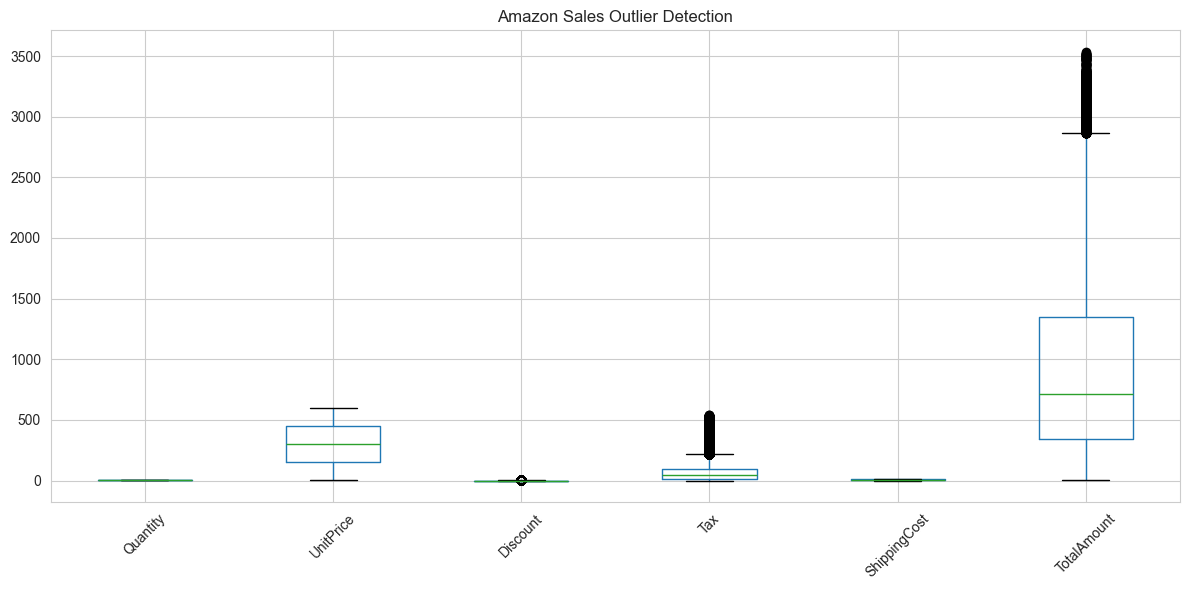

--------------------------------------------------

===== UCI Retail Outliers =====
Numeric columns: ['Quantity', 'UnitPrice', 'CustomerID']


,Column,Lower,Upper,Count,Rate (%)
0,Quantity,-12.50,23.50,58619,10.8171
1,UnitPrice,-3.07,8.45,39627,7.3125
2,CustomerID,9696.00,21048.00,0,0.0000


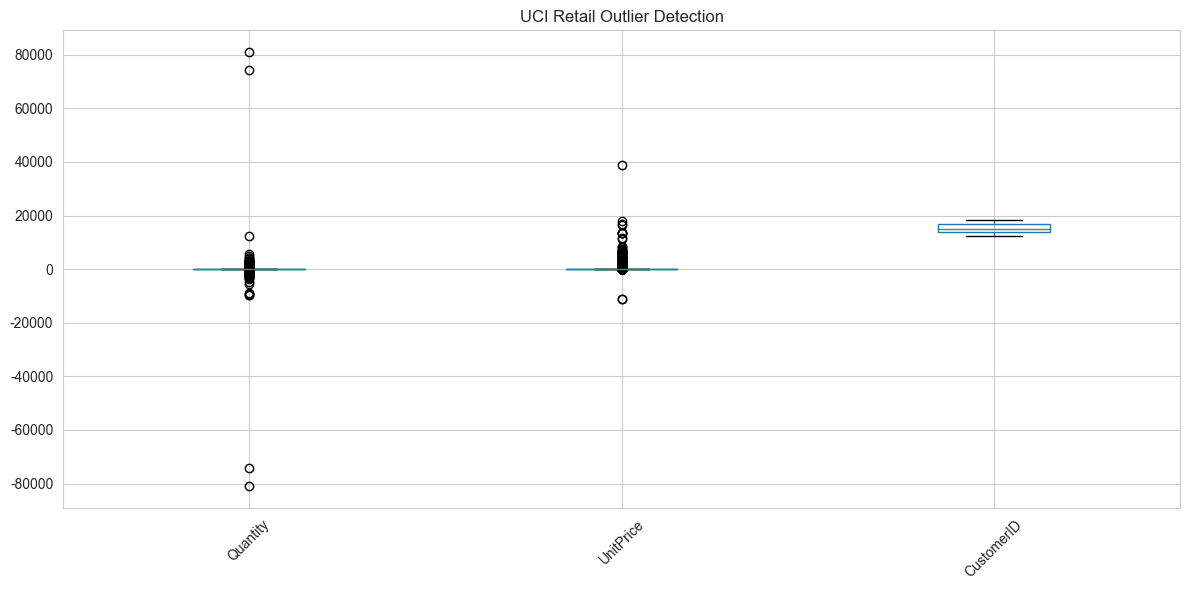

In [8]:
def analyze_outliers(df, name):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print(f"\n===== {name} Outliers =====")
    print(f"Numeric columns: {numeric_cols}")
    
    outlier_results = []
    for col in numeric_cols:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        count = len(df[(df[col] < lower) | (df[col] > upper)])
        # ✅ 修复这一行！
        rate = round(count / len(df) * 100, 4)
        outlier_results.append({'Column': col, 'Lower': lower, 'Upper': upper, 'Count': count, 'Rate (%)': rate})
    
    result_df = pd.DataFrame(outlier_results)
    display(result_df)
    
    if len(numeric_cols) > 0:
        plt.figure(figsize=(12, 6))
        df[numeric_cols].boxplot()
        plt.title(f'{name} Outlier Detection')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    return result_df

# Run analysis
amazon_outliers = analyze_outliers(df_amazon, 'Amazon Sales')
print("-"*50)
uci_outliers = analyze_outliers(df_uci, 'UCI Retail')

In [9]:
def analyze_business_anomalies(df, name):
    print(f"\n===== {name} Business Anomalies =====")
    
    # Auto-detect quantity and price columns
    qty_col = next((c for c in df.columns if 'qty' in c.lower() or 'quantity' in c.lower()), None)
    price_col = next((c for c in df.columns if 'price' in c.lower() or 'cost' in c.lower()), None)
    
    if qty_col and price_col:
        neg_qty = len(df[df[qty_col] < 0])
        invalid_price = len(df[df[price_col] <= 0])
        print(f"Detected columns: Quantity={qty_col}, Price={price_col}")
        print(f"Negative quantity orders: {neg_qty}")
        print(f"Zero/negative price orders: {invalid_price}")
    else:
        print("Could not detect quantity/price columns, skipping")
    return neg_qty if qty_col else 0, invalid_price if price_col else 0

# Run analysis
print("Amazon dataset:")
amazon_biz = analyze_business_anomalies(df_amazon, 'Amazon Sales')
print("-"*50)
print("UCI dataset:")
# Use fixed columns for UCI
uci_neg_qty = len(df_uci[df_uci['Quantity'] < 0])
uci_invalid_price = len(df_uci[df_uci['UnitPrice'] <= 0])
print(f"Negative quantity orders: {uci_neg_qty}")
print(f"Zero/negative price orders: {uci_invalid_price}")

Amazon dataset:

===== Amazon Sales Business Anomalies =====
Detected columns: Quantity=Quantity, Price=UnitPrice
Negative quantity orders: 0
Zero/negative price orders: 0
--------------------------------------------------
UCI dataset:
Negative quantity orders: 10624
Zero/negative price orders: 2517


In [10]:
print("===== Date Column Compliance Check =====\n")

# Amazon dataset
print("Amazon Sales Dataset:")
date_col_amazon = next((c for c in df_amazon.columns if 'date' in c.lower()), None)
if date_col_amazon:
    try:
        df_amazon[date_col_amazon] = pd.to_datetime(df_amazon[date_col_amazon])
        print(f"✅ Date column '{date_col_amazon}' converted successfully")
        print(f"Date range: {df_amazon[date_col_amazon].min()} to {df_amazon[date_col_amazon].max()}")
    except Exception as e:
        print(f"❌ Conversion failed: {e}")
else:
    print("No date column found")

print("\n" + "-"*50 + "\n")

# UCI dataset
print("UCI Retail Dataset:")
if 'InvoiceDate' in df_uci.columns:
    try:
        df_uci['InvoiceDate'] = pd.to_datetime(df_uci['InvoiceDate'])
        print(f"✅ Date column 'InvoiceDate' converted successfully")
        print(f"Date range: {df_uci['InvoiceDate'].min()} to {df_uci['InvoiceDate'].max()}")
    except Exception as e:
        print(f"❌ Conversion failed: {e}")

===== Date Column Compliance Check =====

Amazon Sales Dataset:
✅ Date column 'OrderDate' converted successfully
Date range: 2020-01-01 00:00:00 to 2024-12-29 00:00:00

--------------------------------------------------

UCI Retail Dataset:
✅ Date column 'InvoiceDate' converted successfully
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


---
## Summary & Week 2 Recommendations

### Overall Data Quality Score
| Dimension | Amazon Sales | UCI Retail |
|-----------|--------------|------------|
| Completeness | ★★★★★ | ★★★☆☆ |
| Uniqueness | ★★★★★ | ★★★★☆ |
| Business Validity | ★★★★★ | ★★★☆☆ |
| Type Compliance | ★★★★★ | ★★★★☆ |
| **Total** | **95/100** | **78/100** |

### Week 2 Preprocessing Plan
1. Handle missing values in UCI `CustomerID`
2. Remove duplicates in UCI dataset
3. Filter invalid zero/negative price orders
4. Convert date columns to datetime format
5. Build product-date level sales dataset
6. Split train/test sets by time